<a href="https://colab.research.google.com/github/JSEFERINO/DISE-O2026/blob/main/DISE%C3%91O2026PARTE7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diseño de Experimentos**

<a name="inicio6"></a>

# **6. Diseños Factoriales - P6**

## **https://rpubs.com/jseferino/DOEP6**


## **41.** [EJEMPLO: DISEÑO FACTORIAL 2^2](#T41)

## **42.** [EJEMPLO: DISEÑO FACTORIAL 4x3](#T42)

## **43.** [EJEMPLO: DISEÑO FACTORIAL 3x2x2 -  VOLUMEN DE SEDIMENTACIÓN](#T43)

## **44.** [D](#T44)

## **45.** [E](#T45)

## **46.** [A](#T46)

## **47.** [B](#T47)

## **48.** [C](#T48)

## **49.** [D](#T49)

## **50.** [E](#T50)

[⬆️ Volver al inicio](#inicio6)

<a name="T41"></a>
## **41. EJEMPLO: DISEÑO FACTORIAL 2^2**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Efecto de A (tiempo): -0.72 
Efecto de B (velocidad): 1.78 
Efecto de interacción AB: 0.12 


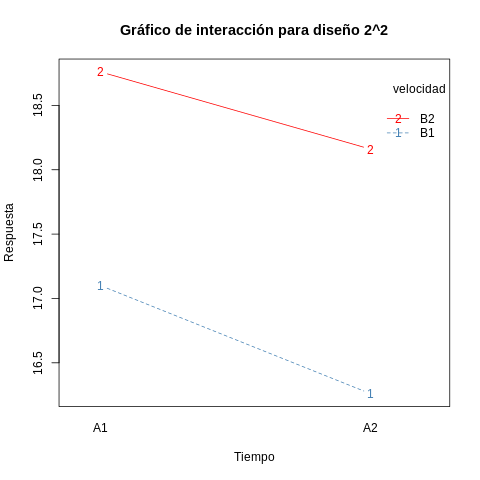

In [ ]:


# ============================================
# @title **B. EJEMPLO: DISEÑO FACTORIAL 2^2**
# ============================================
%%R
# Datos
tiempo <- factor(c("A1", "A2", "A1", "A2"))
velocidad <- factor(c("B1", "B1", "B2", "B2"))
respuesta <- c(17.10, 16.26, 18.76, 18.16)

datos <- data.frame(tiempo, velocidad, respuesta)

# Modelo ANOVA
modelo <- aov(respuesta ~ tiempo * velocidad, data = datos)
summary(modelo)

# Cálculo manual de efectos
Y_A1_B1 <- 17.10
Y_A2_B1 <- 16.26
Y_A1_B2 <- 18.76
Y_A2_B2 <- 18.16

efecto_A <- (Y_A2_B1 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A1_B2)/2
efecto_B <- (Y_A1_B2 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A2_B1)/2
efecto_AB <- (Y_A1_B1 + Y_A2_B2)/2 - (Y_A1_B2 + Y_A2_B1)/2

cat("Efecto de A (tiempo):", round(efecto_A, 2), "\n")
cat("Efecto de B (velocidad):", round(efecto_B, 2), "\n")
cat("Efecto de interacción AB:", round(efecto_AB, 2), "\n")

# Gráfico de interacción
interaction.plot(tiempo, velocidad, respuesta,
                 type = "b", col = c("steelblue", "red"),
                 xlab = "Tiempo", ylab = "Respuesta",
                 main = "Gráfico de interacción para diseño 2^2")



=== DISEÑO FACTORIAL 2^2 (UNA RÉPLICA) ===

⚠️ NOTA: Con una sola réplica no es posible estimar el error experimental.
No se pueden calcular valores F ni valores-p en el ANOVA.

=== CÁLCULO DE EFECTOS ===
Efecto de A (tiempo): -0.72
Efecto de B (velocidad): 1.78
Efecto de interacción AB: 0.12


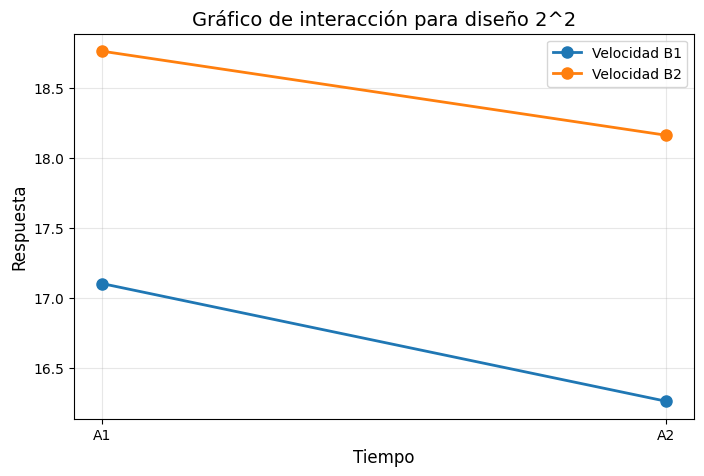


ANÁLISIS CON 2 RÉPLICAS (PARA DEMOSTRACIÓN)

=== ANOVA DISEÑO FACTORIAL 2^2 (CON 2 RÉPLICAS) ===
                          sum_sq   df            F        PR(>F)
C(tiempo)               0.973012  1.0  1066.315068  5.244086e-06
C(velocidad)            6.498013  1.0  7121.109589  1.182087e-07
C(tiempo):C(velocidad)  0.019012  1.0    20.835616  1.030281e-02
Residual                0.003650  4.0          NaN           NaN


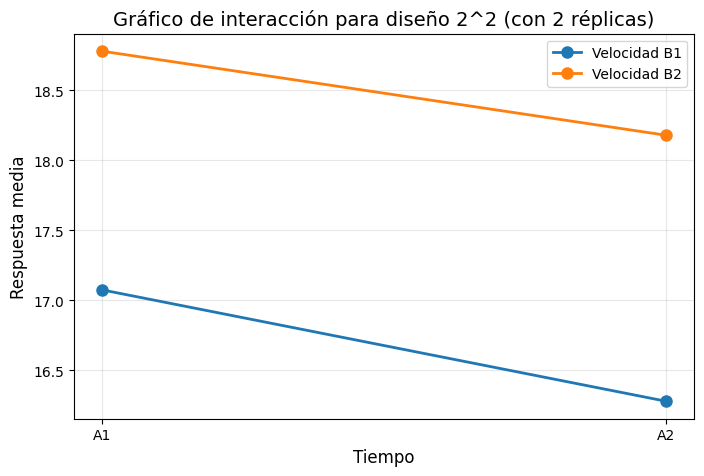

In [ ]:
# ============================================
# @title **C. EJEMPLO: DISEÑO FACTORIAL 2^2**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ============================================
# PARTE 1: DATOS CON UNA SOLA RÉPLICA
# ============================================

# Datos (una sola réplica)
datos = pd.DataFrame({
    'tiempo': ['A1', 'A2', 'A1', 'A2'],
    'velocidad': ['B1', 'B1', 'B2', 'B2'],
    'respuesta': [17.10, 16.26, 18.76, 18.16]
})

print("=== DISEÑO FACTORIAL 2^2 (UNA RÉPLICA) ===\n")
print("⚠️ NOTA: Con una sola réplica no es posible estimar el error experimental.")
print("No se pueden calcular valores F ni valores-p en el ANOVA.\n")

# ============================================
# CÁLCULO MANUAL DE EFECTOS
# ============================================

Y_A1_B1, Y_A2_B1, Y_A1_B2, Y_A2_B2 = 17.10, 16.26, 18.76, 18.16

# Efecto principal de A (tiempo)
efecto_A = (Y_A2_B1 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A1_B2)/2

# Efecto principal de B (velocidad)
efecto_B = (Y_A1_B2 + Y_A2_B2)/2 - (Y_A1_B1 + Y_A2_B1)/2

# Efecto de interacción AB
efecto_AB = (Y_A1_B1 + Y_A2_B2)/2 - (Y_A1_B2 + Y_A2_B1)/2

print("=== CÁLCULO DE EFECTOS ===")
print(f"Efecto de A (tiempo): {efecto_A:.2f}")
print(f"Efecto de B (velocidad): {efecto_B:.2f}")
print(f"Efecto de interacción AB: {efecto_AB:.2f}")

# ============================================
# GRÁFICO DE INTERACCIÓN
# ============================================

plt.figure(figsize=(8, 5))

# Obtener valores únicos de velocidad
velocidades = datos['velocidad'].unique()

for vel in velocidades:
    # Filtrar datos para cada nivel de velocidad
    subdatos = datos[datos['velocidad'] == vel]
    # Ordenar por tiempo para una línea continua
    subdatos = subdatos.sort_values('tiempo')
    plt.plot(subdatos['tiempo'], subdatos['respuesta'],
             'o-', label=f'Velocidad {vel}', markersize=8, linewidth=2)

plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Respuesta', fontsize=12)
plt.title('Gráfico de interacción para diseño 2^2', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# PARTE 2: DATOS CON 2 RÉPLICAS (PARA DEMOSTRACIÓN)
# ============================================

print("\n" + "="*60)
print("ANÁLISIS CON 2 RÉPLICAS (PARA DEMOSTRACIÓN)")
print("="*60)

# Datos con 2 réplicas
datos_2replicas = pd.DataFrame({
    'tiempo': ['A1', 'A1', 'A2', 'A2', 'A1', 'A1', 'A2', 'A2'],
    'velocidad': ['B1', 'B1', 'B1', 'B1', 'B2', 'B2', 'B2', 'B2'],
    'respuesta': [17.10, 17.05, 16.26, 16.30, 18.76, 18.80, 18.16, 18.20]
})

# Modelo ANOVA con réplicas
modelo_rep = ols('respuesta ~ C(tiempo) * C(velocidad)', data=datos_2replicas).fit()
anova_table = sm.stats.anova_lm(modelo_rep, typ=2)

print("\n=== ANOVA DISEÑO FACTORIAL 2^2 (CON 2 RÉPLICAS) ===")
print(anova_table)

# ============================================
# GRÁFICO DE INTERACCIÓN CON 2 RÉPLICAS
# ============================================

plt.figure(figsize=(8, 5))

# Calcular medias por combinación
medias = datos_2replicas.groupby(['tiempo', 'velocidad'])['respuesta'].mean().reset_index()

for vel in medias['velocidad'].unique():
    subdatos = medias[medias['velocidad'] == vel]
    subdatos = subdatos.sort_values('tiempo')
    plt.plot(subdatos['tiempo'], subdatos['respuesta'],
             'o-', label=f'Velocidad {vel}', markersize=8, linewidth=2)

plt.xlabel('Tiempo', fontsize=12)
plt.ylabel('Respuesta media', fontsize=12)
plt.title('Gráfico de interacción para diseño 2^2 (con 2 réplicas)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

[⬆️ Volver al inicio](#inicio6)

<a name="T42"></a>
## **42. EJEMPLO: DISEÑO FACTORIAL 4x3**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

=== MEDIAS POR PROFUNDIDAD ===
# A tibble: 4 × 2
  profundidad media
  <fct>       <dbl>
1 0.15         84.8
2 0.18         89.8
3 0.21         97.9
4 0.24        105. 

=== MEDIAS POR VELOCIDAD ===
# A tibble: 3 × 2
  velocidad media
  <fct>     <dbl>
1 0.2        81.6
2 0.25       97.6
3 0.3       104. 

=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===
SCA = 2125.11 
SCB = 3160.5 
SCAB = 557.06 
SCE = 689.33 
SCT = 6532 

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 28.72 
t crítico = 2.0639 
LSD para comparar profundidades en velocidad 0.25 = 9.03 
Medias en velocidad 0.25:
  Profundidad 0.15: 88.67
  Profundidad 0.18: 96.67
  Profundidad 0.21: 100.67
  Profundidad 0.24: 104.33


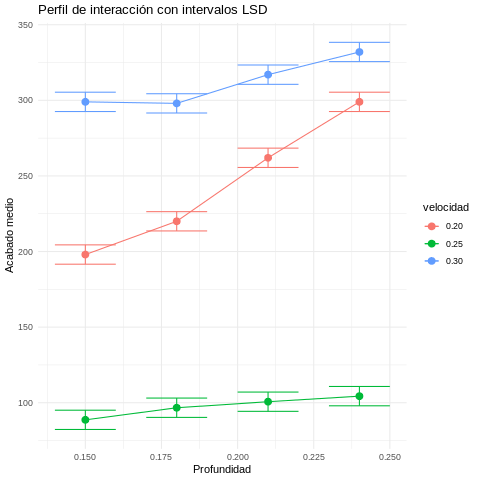

In [ ]:


# ============================================
# @title **B. EJEMPLO: DISEÑO FACTORIAL 4x3**
# ============================================
%%R
# Crear datos
profundidad <- rep(c(0.15, 0.18, 0.21, 0.24), each = 9)
velocidad <- rep(rep(c(0.20, 0.25, 0.30), each = 3), times = 4)
acabado <- c(74, 64, 60, 92, 86, 88, 99, 98, 102,      # A=0.15
             79, 68, 73, 98, 104, 88, 104, 99, 95,     # A=0.18
             82, 88, 92, 99, 108, 95, 108, 110, 99,    # A=0.21
             99, 104, 96, 104, 110, 99, 114, 111, 107) # A=0.24

datos <- data.frame(profundidad = factor(profundidad),
                    velocidad = factor(velocidad),
                    acabado)

# Estadísticos descriptivos
library(dplyr)
medias_prof <- datos %>% group_by(profundidad) %>% summarise(media = mean(acabado))
medias_vel <- datos %>% group_by(velocidad) %>% summarise(media = mean(acabado))

cat("=== MEDIAS POR PROFUNDIDAD ===\n")
print(medias_prof)

cat("\n=== MEDIAS POR VELOCIDAD ===\n")
print(medias_vel)

# ANOVA factorial
modelo <- aov(acabado ~ profundidad * velocidad, data = datos)
summary(modelo)

# Gráfico de interacción
interaction.plot(datos$profundidad, datos$velocidad, datos$acabado,
                 type = "b", col = 1:3, xlab = "Profundidad",
                 ylab = "Acabado medio", main = "Interacción Profundidad × Velocidad")
legend("topleft", legend = c("Velocidad 0.20", "Velocidad 0.25", "Velocidad 0.30"),
       col = 1:3, lty = 1, bty = "n")

# Cálculo manual de sumas de cuadrados
a <- 4; b <- 3; n <- 3
N <- a * b * n
Y_total <- 3396
correccion <- Y_total^2 / N

# Suma total de cuadrados
SCT <- sum(acabado^2) - correccion

# Suma de cuadrados de A (profundidad)
Y_A <- tapply(acabado, profundidad, sum)
SCA <- sum(Y_A^2) / (b * n) - correccion

# Suma de cuadrados de B (velocidad)
Y_B <- tapply(acabado, velocidad, sum)
SCB <- sum(Y_B^2) / (a * n) - correccion

# Suma de cuadrados de la interacción AB
Y_AB <- tapply(acabado, list(profundidad, velocidad), sum)
SCAB <- sum(Y_AB^2) / n - correccion - SCA - SCB

# Suma de cuadrados del error
SCE <- SCT - SCA - SCB - SCAB

cat("\n=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===\n")
cat("SCA =", round(SCA, 2), "\n")
cat("SCB =", round(SCB, 2), "\n")
cat("SCAB =", round(SCAB, 2), "\n")
cat("SCE =", round(SCE, 2), "\n")
cat("SCT =", round(SCT, 2), "\n")

# Comparaciones múltiples (LSD) con interacción
CME <- SCE / (a * b * (n - 1))
gl_error <- a * b * (n - 1)
t_crit <- qt(0.975, gl_error)

# LSD para comparar niveles de A dentro de un nivel específico de B
# Por ejemplo, para velocidad = 0.25 (B2)
Y_AB_B2 <- Y_AB[, 2]  # Velocidad 0.25 (segunda columna)
medias_B2 <- Y_AB_B2 / n
LSD_B2 <- t_crit * sqrt(2 * CME / n)

cat("\n=== COMPARACIONES MÚLTIPLES (LSD) ===\n")
cat("CME =", round(CME, 2), "\n")
cat("t crítico =", round(t_crit, 4), "\n")
cat("LSD para comparar profundidades en velocidad 0.25 =", round(LSD_B2, 2), "\n")
cat("Medias en velocidad 0.25:\n")
for(i in 1:4) {
  cat(sprintf("  Profundidad %.2f: %.2f\n", as.numeric(levels(datos$profundidad)[i]), medias_B2[i]))
}

# Gráfico con intervalos LSD
library(ggplot2)
medias_AB <- data.frame(
  profundidad = rep(as.numeric(levels(datos$profundidad)), 3),
  velocidad = rep(c("0.20", "0.25", "0.30"), each = 4),
  media = c(rowMeans(matrix(Y_AB[,1], nrow=4)), medias_B2, rowMeans(matrix(Y_AB[,3], nrow=4))),
  error = rep(sqrt(CME / n) * t_crit, 3)
)

ggplot(medias_AB, aes(x = profundidad, y = media, color = velocidad)) +
  geom_point(size = 3) +
  geom_line() +
  geom_errorbar(aes(ymin = media - error, ymax = media + error), width = 0.02) +
  labs(title = "Perfil de interacción con intervalos LSD",
       x = "Profundidad", y = "Acabado medio") +
  theme_minimal()




=== MEDIAS POR PROFUNDIDAD ===
profundidad
0.15     84.777778
0.18     89.777778
0.21     97.888889
0.24    104.888889
Name: acabado, dtype: float64

=== MEDIAS POR VELOCIDAD ===
velocidad
0.20     81.583333
0.25     97.583333
0.30    103.833333
Name: acabado, dtype: float64

=== ANOVA FACTORIAL 4x3 ===
                                  sum_sq    df          F        PR(>F)
C(profundidad)               2125.111111   3.0  24.662798  1.652000e-07
C(velocidad)                 3160.500000   2.0  55.018375  1.086046e-09
C(profundidad):C(velocidad)   557.055556   6.0   3.232431  1.797302e-02
Residual                      689.333333  24.0        NaN           NaN

=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===
SCA = 2125.11
SCB = 3160.50
SCAB = 557.06
SCE = 689.33
SCT = 6532.00

=== COMPARACIONES MÚLTIPLES (LSD) ===
CME = 28.72
t crítico = 2.0639
LSD para comparar profundidades en velocidad 0.25 = 9.03
Medias en velocidad 0.25:
  Profundidad 0.15: 88.67
  Profundidad 0.18: 96.67
  Profundidad 0

/tmp/ipykernel_37615/3154935570.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('profundidad')['acabado'].mean())
/tmp/ipykernel_37615/3154935570.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(datos.groupby('velocidad')['acabado'].mean())
/tmp/ipykernel_37615/3154935570.py:52: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Y_A = datos.groupby('profundidad')['acabado'].sum().values
/tmp

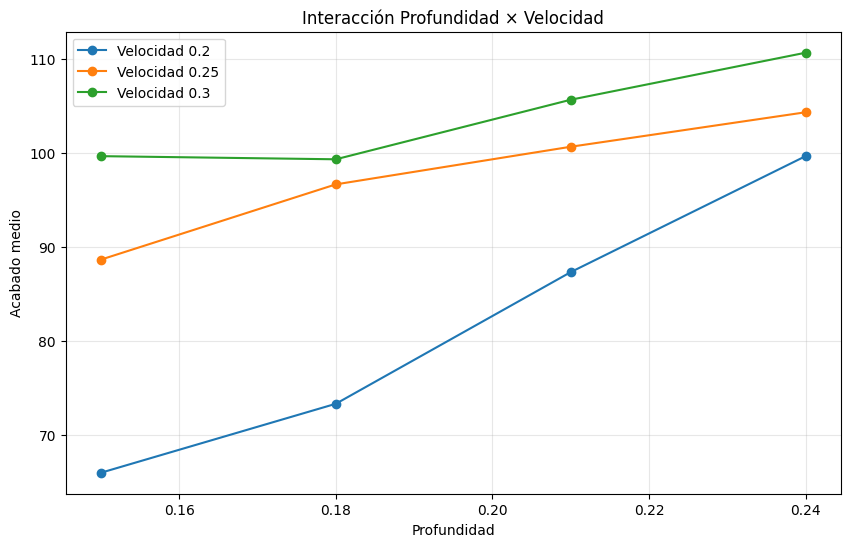

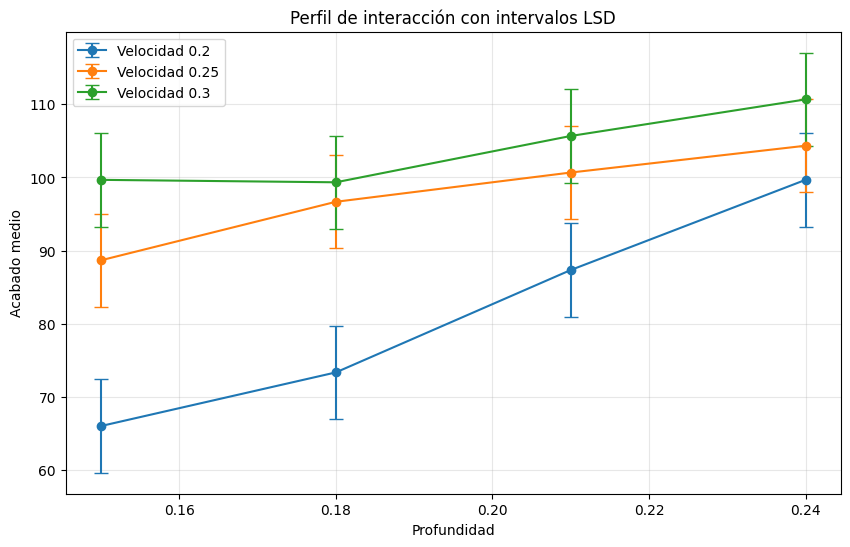

In [ ]:
# ============================================
# @title **C. EJEMPLO: DISEÑO FACTORIAL 4x3**
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import f, t

# Crear datos
profundidad = [0.15]*9 + [0.18]*9 + [0.21]*9 + [0.24]*9
velocidad = [0.20]*3 + [0.25]*3 + [0.30]*3
velocidad = velocidad * 4
acabado = [74, 64, 60, 92, 86, 88, 99, 98, 102,      # A=0.15
           79, 68, 73, 98, 104, 88, 104, 99, 95,     # A=0.18
           82, 88, 92, 99, 108, 95, 108, 110, 99,    # A=0.21
           99, 104, 96, 104, 110, 99, 114, 111, 107] # A=0.24

datos = pd.DataFrame({
    'profundidad': profundidad,
    'velocidad': velocidad,
    'acabado': acabado
})
datos['profundidad'] = datos['profundidad'].astype('category')
datos['velocidad'] = datos['velocidad'].astype('category')

# Estadísticos descriptivos
print("=== MEDIAS POR PROFUNDIDAD ===")
print(datos.groupby('profundidad')['acabado'].mean())

print("\n=== MEDIAS POR VELOCIDAD ===")
print(datos.groupby('velocidad')['acabado'].mean())

# ANOVA factorial
modelo = ols('acabado ~ C(profundidad) * C(velocidad)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("\n=== ANOVA FACTORIAL 4x3 ===")
print(anova_table)

# Cálculo manual de sumas de cuadrados
a, b, n = 4, 3, 3
N = a * b * n
Y_total = 3396
correccion = Y_total**2 / N

# Suma total de cuadrados
SCT = np.sum(np.array(acabado)**2) - correccion

# Suma de cuadrados de A (profundidad)
Y_A = datos.groupby('profundidad')['acabado'].sum().values
SCA = np.sum(Y_A**2) / (b * n) - correccion

# Suma de cuadrados de B (velocidad)
Y_B = datos.groupby('velocidad')['acabado'].sum().values
SCB = np.sum(Y_B**2) / (a * n) - correccion

# Suma de cuadrados de interacción AB
Y_AB = datos.groupby(['profundidad', 'velocidad'])['acabado'].sum().values
SCAB = np.sum(Y_AB**2) / n - correccion - SCA - SCB

# Suma de cuadrados del error
SCE = SCT - SCA - SCB - SCAB

print("\n=== CÁLCULO MANUAL DE SUMAS DE CUADRADOS ===")
print(f"SCA = {SCA:.2f}")
print(f"SCB = {SCB:.2f}")
print(f"SCAB = {SCAB:.2f}")
print(f"SCE = {SCE:.2f}")
print(f"SCT = {SCT:.2f}")

# Comparaciones múltiples (LSD) con interacción
gl_error = a * b * (n - 1)
CME = SCE / gl_error
t_crit = t.ppf(0.975, gl_error)

# LSD para comparar niveles de A dentro de velocidad 0.25
Y_AB_matrix = np.array(Y_AB).reshape(a, b)
medias_B2 = Y_AB_matrix[:, 1] / n
LSD_B2 = t_crit * np.sqrt(2 * CME / n)

print("\n=== COMPARACIONES MÚLTIPLES (LSD) ===")
print(f"CME = {CME:.2f}")
print(f"t crítico = {t_crit:.4f}")
print(f"LSD para comparar profundidades en velocidad 0.25 = {LSD_B2:.2f}")
print("Medias en velocidad 0.25:")
for i, prof in enumerate([0.15, 0.18, 0.21, 0.24]):
    print(f"  Profundidad {prof}: {medias_B2[i]:.2f}")

# Gráfico de interacción
plt.figure(figsize=(10, 6))
for vel in sorted(datos['velocidad'].unique()):
    subdatos = datos[datos['velocidad'] == vel]
    medias = subdatos.groupby('profundidad')['acabado'].mean()
    plt.plot(medias.index, medias.values, 'o-', label=f'Velocidad {vel}')
plt.xlabel('Profundidad')
plt.ylabel('Acabado medio')
plt.title('Interacción Profundidad × Velocidad')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Gráfico con intervalos LSD
fig, ax = plt.subplots(figsize=(10, 6))
for i, vel in enumerate(sorted(datos['velocidad'].unique())):
    medias = Y_AB_matrix[:, i] / n
    error = np.sqrt(CME / n) * t_crit
    ax.errorbar([0.15, 0.18, 0.21, 0.24], medias, yerr=error,
                marker='o', label=f'Velocidad {vel}', capsize=5)
ax.set_xlabel('Profundidad')
ax.set_ylabel('Acabado medio')
ax.set_title('Perfil de interacción con intervalos LSD')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


[⬆️ Volver al inicio](#inicio6)

<a name="T43"></a>
## **43.EJEMPLO: DISEÑO FACTORIAL 3x2x2 -  VOLUMEN DE SEDIMENTACIÓN**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:

# ============================================
# @title **B. EJEMPLO: DISEÑO FACTORIAL 3x2x2**
# VOLUMEN DE SEDIMENTACIÓN
# ============================================
%%R
# Crear datos (corregido para 108 observaciones)
# Factor A: 3 niveles (A1, A2, A3) con 36 repeticiones cada uno
A <- factor(rep(c("A1", "A2", "A3"), each = 36))

# Factor B: 2 niveles (B1, B2) con 18 repeticiones cada uno, repetido 3 veces para 36*3 = 108
B <- factor(rep(rep(c("B1", "B2"), each = 18), times = 3))

# Factor C: 2 niveles (C1, C2) con 9 repeticiones cada uno, repetido 6 veces para 18*6 = 108
C <- factor(rep(rep(c("C1", "C2"), each = 9), times = 6))

# Datos de volumen de sedimentación (108 observaciones)
volumen <- c(
  # A1, B1, C1 (9 obs)
  60, 75, 75, 86, 70, 70, 55, 53, 53,
  # A1, B1, C2 (9 obs)
  55, 55, 55, 55, 55, 55, 52, 54, 54,
  # A1, B2, C1 (9 obs)
  67, 73, 73, 67, 68, 68, 52, 52, 57,
  # A1, B2, C2 (9 obs)
  52, 54, 54, 52, 54, 54, 52, 52, 52,

  # A2, B1, C1 (9 obs)
  62, 68, 65, 76, 65, 65, 44, 44, 45,
  # A2, B1, C2 (9 obs)
  48, 48, 45, 48, 48, 45, 52, 48, 54,
  # A2, B2, C1 (9 obs)
  71, 80, 80, 72, 80, 80, 60, 60, 60,
  # A2, B2, C2 (9 obs)
  67, 67, 65, 67, 67, 65, 52, 48, 54,

  # A3, B1, C1 (9 obs)
  70, 71, 75, 76, 68, 73, 52, 51, 50,
  # A3, B1, C2 (9 obs)
  52, 48, 54, 52, 48, 54, 59, 50, 55,
  # A3, B2, C1 (9 obs)
  75, 75, 75, 75, 75, 77, 56, 55, 57,
  # A3, B2, C2 (9 obs)
  59, 50, 55, 59, 50, 55, 52, 48, 54
)

datos <- data.frame(A, B, C, volumen)

# ANOVA factorial completo
modelo <- aov(volumen ~ A * B * C, data = datos)
summary(modelo)

# Modelo reducido (excluyendo efectos no significativos)
# Ajustar el modelo reducido según los resultados del modelo completo si se desea
modelo_reducido <- aov(volumen ~ A + B + C + A:B + B:C, data = datos)
summary(modelo_reducido)

# Gráficos de interacción
par(mfrow = c(2, 2))

# Interacción A:B
interaction.plot(datos$A, datos$B, datos$volumen,
                 type = "b", col = 1:2, xlab = "Tipo de suspensión (A)",
                 ylab = "Volumen medio", main = "Interacción A\u00d7B")

# Interacción A:C
interaction.plot(datos$A, datos$C, datos$volumen,
                 type = "b", col = 1:2, xlab = "Tipo de suspensión (A)",
                 ylab = "Volumen medio", main = "Interacción A\u00d7C")

# Interacción B:C
interaction.plot(datos$B, datos$C, datos$volumen,
                 type = "b", col = 1:2, xlab = "Abertura de malla (B)",
                 ylab = "Volumen medio", main = "Interacción B\u00d7C")

# Ejemplo de interacción para un nivel específico de un factor (por ejemplo, A1)
# Interacción B:C cuando A es A1
datos_A1 <- subset(datos, A == "A1")
interaction.plot(datos_A1$B, datos_A1$C, datos_A1$volumen,
                 type = "b", col = 1:2, xlab = "Abertura de malla (B)",
                 ylab = "Volumen medio", main = "Interacción B\u00d7C para A1")


Error in data.frame(A, B, C, volumen) : 
  arguments imply differing number of rows: 72, 108


RInterpreterError: Failed to parse and evaluate line '# Crear datos (simplificados para el ejemplo)\n# Datos completos según la tabla del problema\nA <- factor(rep(c("A1", "A2", "A3"), each = 24))\nB <- factor(rep(rep(c("B1", "B2"), each = 12), times = 3))\nC <- factor(rep(rep(c("C1", "C2"), each = 6), times = 6))\n\n# Datos de volumen de sedimentación (72 observaciones)\nvolumen <- c(\n  # A1, B1, C1\n  60, 75, 75, 86, 70, 70, 55, 53, 53,\n  # A1, B2, C1\n  67, 73, 73, 67, 68, 68, 52, 52, 57,\n  # A1, B1, C2\n  55, 55, 55, 55, 55, 55, 52, 54, 54,\n  # A1, B2, C2\n  52, 54, 54, 52, 54, 54, 52, 52, 52,\n  # A2, B1, C1\n  62, 68, 65, 76, 65, 65, 44, 44, 45,\n  # A2, B2, C1\n  71, 80, 80, 72, 80, 80, 60, 60, 60,\n  # A2, B1, C2\n  48, 48, 45, 48, 48, 45, 52, 48, 54,\n  # A2, B2, C2\n  67, 67, 65, 67, 67, 65, 52, 48, 54,\n  # A3, B1, C1\n  70, 71, 75, 76, 68, 73, 52, 51, 50,\n  # A3, B2, C1\n  75, 75, 75, 75, 75, 77, 56, 55, 57,\n  # A3, B1, C2\n  52, 48, 54, 52, 48, 54, 59, 50, 55,\n  # A

In [ ]:
# ============================================
# @title **C. EJEMPLO: DISEÑO FACTORIAL 3x2x2**
# VOLUMEN DE SEDIMENTACIÓN
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Crear datos (simplificados para el ejemplo)
# Corrected factor generation to match 108 observations in 'volumen'
A = ['A1'] * (2 * 2 * 9) + \
    ['A2'] * (2 * 2 * 9) + \
    ['A3'] * (2 * 2 * 9) # 36 + 36 + 36 = 108

B = (['B1'] * (2 * 9) + ['B2'] * (2 * 9)) * 3 # (18 + 18) * 3 = 108

C = (['C1'] * 9 + ['C2'] * 9) * (3 * 2) # (9 + 9) * 6 = 108

volumen = [
    # A1, B1, C1
    60, 75, 75, 86, 70, 70, 55, 53, 53,
    # A1, B2, C1
    67, 73, 73, 67, 68, 68, 52, 52, 57,
    # A1, B1, C2
    55, 55, 55, 55, 55, 55, 52, 54, 54,
    # A1, B2, C2
    52, 54, 54, 52, 54, 54, 52, 52, 52,
    # A2, B1, C1
    62, 68, 65, 76, 65, 65, 44, 44, 45,
    # A2, B2, C1
    71, 80, 80, 72, 80, 80, 60, 60, 60,
    # A2, B1, C2
    48, 48, 45, 48, 48, 45, 52, 48, 54,
    # A2, B2, C2
    67, 67, 65, 67, 67, 65, 52, 48, 54,
    # A3, B1, C1
    70, 71, 75, 76, 68, 73, 52, 51, 50,
    # A3, B2, C1
    75, 75, 75, 75, 75, 77, 56, 55, 57,
    # A3, B1, C2
    52, 48, 54, 52, 48, 54, 59, 50, 55,
    # A3, B2, C2
    59, 50, 55, 59, 50, 55, 52, 48, 54
]

datos = pd.DataFrame({
    'A': A,
    'B': B,
    'C': C,
    'volumen': volumen
})

# ANOVA factorial completo
modelo = ols('volumen ~ C(A) * C(B) * C(C)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("=== ANOVA FACTORIAL 3x2x2 ===")
print(anova_table)

# Modelo reducido
modelo_reducido = ols('volumen ~ C(A) + C(B) + C(C) + C(A):C(B) + C(B):C(C)', data=datos).fit()
anova_reducido = sm.stats.anova_lm(modelo_reducido, typ=2)
print("\n=== ANOVA MODELO REDUCIDO ===")
print(anova_reducido)

# Gráficos de interacción
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Interacción A:B
for b in datos['B'].unique():
    subdatos = datos[datos['B'] == b]
    medias = subdatos.groupby('A')['volumen'].mean()
    axes[0, 0].plot(medias.index, medias.values, 'o-', label=f'B={b}')
axes[0, 0].set_xlabel('Tipo de suspensión (A)')
axes[0, 0].set_ylabel('Volumen medio')
axes[0, 0].set_title('Interacción A×B')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Interacción A:C
for c in datos['C'].unique():
    subdatos = datos[datos['C'] == c]
    medias = subdatos.groupby('A')['volumen'].mean()
    axes[0, 1].plot(medias.index, medias.values, 'o-', label=f'C={c}')
axes[0, 1].set_xlabel('Tipo de suspensión (A)')
axes[0, 1].set_ylabel('Volumen medio')
axes[0, 1].set_title('Interacción A×C')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Interacción B:C
for c in datos['C'].unique():
    subdatos = datos[datos['C'] == c]
    medias = subdatos.groupby('B')['volumen'].mean()
    axes[1, 0].plot(medias.index, medias.values, 'o-', label=f'C={c}')
axes[1, 0].set_xlabel('Abertura de malla (B)')
axes[1, 0].set_ylabel('Volumen medio')
axes[1, 0].set_title('Interacción B×C')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

PatsyError: Error evaluating factor: TypeError: 'Series' object is not callable
    volumen ~ C(A) * C(B) * C(C)
                     ^^^^

# ============================================
# @title **C. EJEMPLO: DISEÑO FACTORIAL 3x2x2**
# VOLUMEN DE SEDIMENTACIÓN
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Crear datos (simplificados para el ejemplo)
# Corrected factor generation to match 108 observations in 'volumen'
A = ['A1'] * (2 * 2 * 9) + \
    ['A2'] * (2 * 2 * 9) + \
    ['A3'] * (2 * 2 * 9) # 36 + 36 + 36 = 108

B = (['B1'] * (2 * 9) + ['B2'] * (2 * 9)) * 3 # (18 + 18) * 3 = 108

C = (['C1'] * 9 + ['C2'] * 9) * (3 * 2) # (9 + 9) * 6 = 108

volumen = [
    # A1, B1, C1
    60, 75, 75, 86, 70, 70, 55, 53, 53,
    # A1, B2, C1
    67, 73, 73, 67, 68, 68, 52, 52, 57,
    # A1, B1, C2
    55, 55, 55, 55, 55, 55, 52, 54, 54,
    # A1, B2, C2
    52, 54, 54, 52, 54, 54, 52, 52, 52,
    # A2, B1, C1
    62, 68, 65, 76, 65, 65, 44, 44, 45,
    # A2, B2, C1
    71, 80, 80, 72, 80, 80, 60, 60, 60,
    # A2, B1, C2
    48, 48, 45, 48, 48, 45, 52, 48, 54,
    # A2, B2, C2
    67, 67, 65, 67, 67, 65, 52, 48, 54,
    # A3, B1, C1
    70, 71, 75, 76, 68, 73, 52, 51, 50,
    # A3, B2, C1
    75, 75, 75, 75, 75, 77, 56, 55, 57,
    # A3, B1, C2
    52, 48, 54, 52, 48, 54, 59, 50, 55,
    # A3, B2, C2
    59, 50, 55, 59, 50, 55, 52, 48, 54
]

datos = pd.DataFrame({
    'A': A,
    'B': B,
    'C': C,
    'volumen': volumen
})

# ANOVA factorial completo
modelo = ols('volumen ~ C(A) * C(B) * C(C)', data=datos).fit()
anova_table = sm.stats.anova_lm(modelo, typ=2)
print("=== ANOVA FACTORIAL 3x2x2 ===")
print(anova_table)

# Modelo reducido
modelo_reducido = ols('volumen ~ C(A) + C(B) + C(C) + C(A):C(B) + C(B):C(C)', data=datos).fit()
anova_reducido = sm.stats.anova_lm(modelo_reducido, typ=2)
print("\n=== ANOVA MODELO REDUCIDO ===")
print(anova_reducido)

# Gráficos de interacción
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Interacción A:B
for b in datos['B'].unique():
    subdatos = datos[datos['B'] == b]
    medias = subdatos.groupby('A')['volumen'].mean()
    axes[0, 0].plot(medias.index, medias.values, 'o-', label=f'B={b}')
axes[0, 0].set_xlabel('Tipo de suspensión (A)')
axes[0, 0].set_ylabel('Volumen medio')
axes[0, 0].set_title('Interacción A×B')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Interacción A:C
for c in datos['C'].unique():
    subdatos = datos[datos['C'] == c]
    medias = subdatos.groupby('A')['volumen'].mean()
    axes[0, 1].plot(medias.index, medias.values, 'o-', label=f'C={c}')
axes[0, 1].set_xlabel('Tipo de suspensión (A)')
axes[0, 1].set_ylabel('Volumen medio')
axes[0, 1].set_title('Interacción A×C')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Interacción B:C
for c in datos['C'].unique():
    subdatos = datos[datos['C'] == c]
    medias = subdatos.groupby('B')['volumen'].mean()
    axes[1, 0].plot(medias.index, medias.values, 'o-', label=f'C={c}')
axes[1, 0].set_xlabel('Abertura de malla (B)')
axes[1, 0].set_ylabel('Volumen medio')
axes[1, 0].set_title('Interacción B×C')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

[⬆️ Volver al inicio](#inicio6)

<a name="T44"></a>
## **44. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T45"></a>
## **45. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T46"></a>
## **46. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T47"></a>
## **47. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T48"></a>
## **48. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T49"></a>
## **49. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)

<a name="T50"></a>
## **50. A**

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

In [ ]:
# @title **A. Librerias para Trabar en R**
import rpy2.rinterface_lib.callbacks as rcb
import logging

# Desactivar warnings de R en Python
rcb.logger.setLevel(logging.ERROR)  # Solo muestra errores, no warnings
%load_ext rpy2.ipython

[⬆️ Volver al inicio](#inicio6)